In [4]:
import pandas as pd

In [5]:
from google.colab import files

In [6]:
!unzip "archive (1).zip"

Archive:  archive (1).zip
  inflating: Unemployment in India.csv  
  inflating: Unemployment_Rate_upto_11_2020.csv  


In [7]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [9]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [10]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [12]:
df.shape

(768, 7)

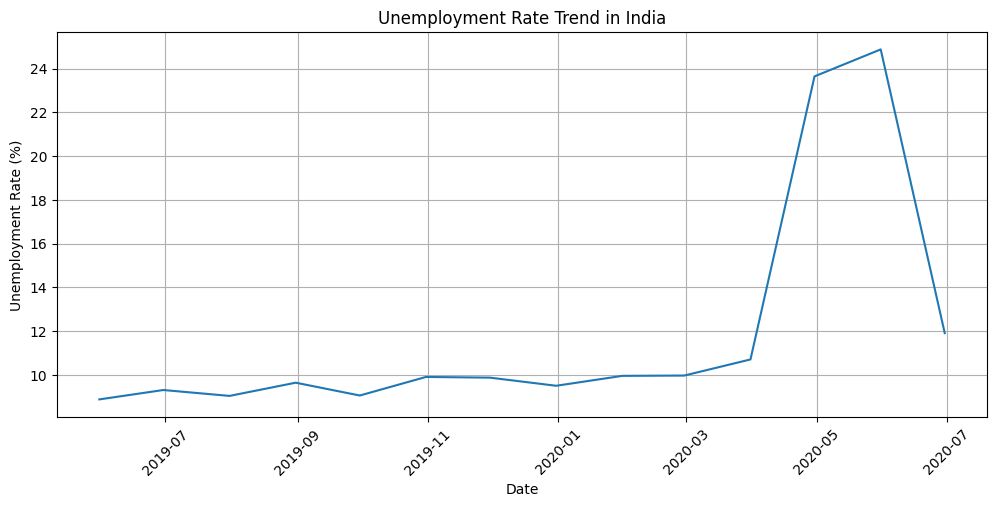

In [13]:
import matplotlib.pyplot as plt

monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_unemployment.index, monthly_unemployment.values)
plt.title('Unemployment Rate Trend in India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [14]:
covid_before = df[df['Date'] < '2020-03-01']
covid_during = df[df['Date'] >= '2020-03-01']

print("Average unemployment rate before COVID:",
      covid_before['Estimated Unemployment Rate (%)'].mean())

print("Average unemployment rate during COVID:",
      covid_during['Estimated Unemployment Rate (%)'].mean())

Average unemployment rate before COVID: 9.509533582089553
Average unemployment rate during COVID: 17.774362745098042


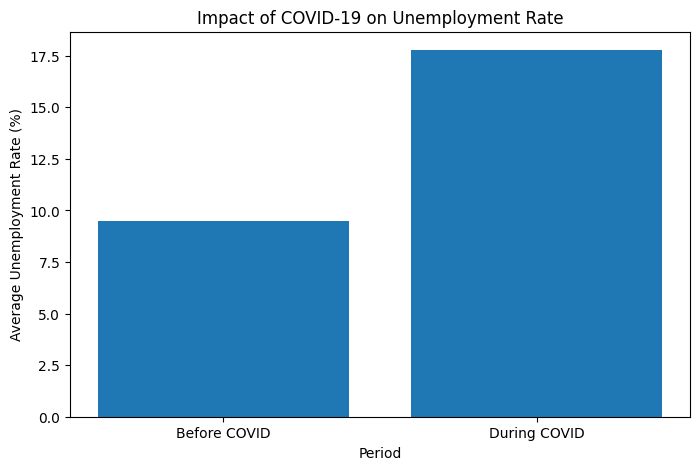

In [15]:
import matplotlib.pyplot as plt

periods = ['Before COVID', 'During COVID']
rates = [
    covid_before['Estimated Unemployment Rate (%)'].mean(),
    covid_during['Estimated Unemployment Rate (%)'].mean()
]

plt.figure(figsize=(8, 5))
plt.bar(periods, rates)
plt.title('Impact of COVID-19 on Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

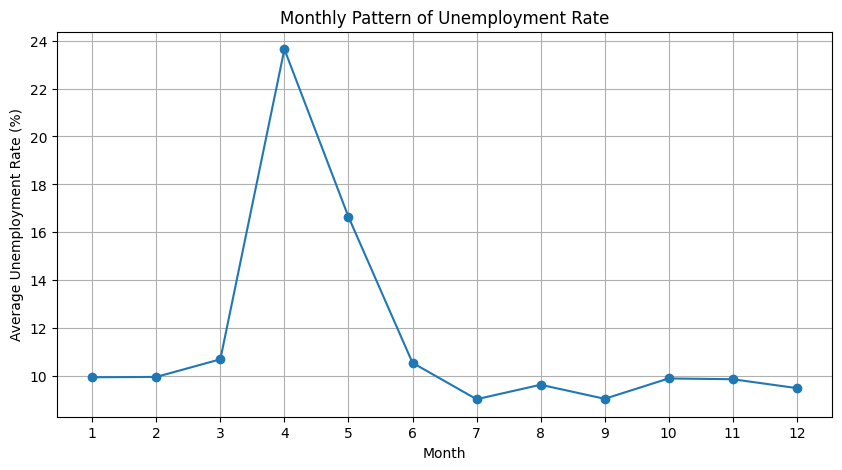

In [16]:
df['Month'] = df['Date'].dt.month

monthly_pattern = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker='o')
plt.title('Monthly Pattern of Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [17]:
highest_month = monthly_pattern.idxmax()
lowest_month = monthly_pattern.idxmin()

print("Month with highest average unemployment:", highest_month)
print("Month with lowest average unemployment:", lowest_month)

print("\nHighest unemployment rate:",
      monthly_pattern.max())

print("Lowest unemployment rate:",
      monthly_pattern.min())

Month with highest average unemployment: 4.0
Month with lowest average unemployment: 7.0

Highest unemployment rate: 23.64156862745098
Lowest unemployment rate: 9.033888888888889


In [18]:
print("KEY FINDINGS")
print("----------------------------")

print("1. Average unemployment before COVID:",
      round(covid_before['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("2. Average unemployment during COVID:",
      round(covid_during['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("3. Highest unemployment month:", highest_month)

print("4. Lowest unemployment month:", lowest_month)

print("5. Highest unemployment rate:",
      round(monthly_pattern.max(), 2), "%")

print("6. Lowest unemployment rate:",
      round(monthly_pattern.min(), 2), "%")

KEY FINDINGS
----------------------------
1. Average unemployment before COVID: 9.51 %
2. Average unemployment during COVID: 17.77 %
3. Highest unemployment month: 4.0
4. Lowest unemployment month: 7.0
5. Highest unemployment rate: 23.64 %
6. Lowest unemployment rate: 9.03 %


In [3]:
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


## Conclusion

The unemployment analysis shows that unemployment changed significantly during the observed period. The average unemployment rate increased from 9.51% before COVID-19 to 17.77% during the COVID-19 period.

The monthly analysis also shows variations in unemployment rates across different months. The highest monthly average was observed in April, while the lowest was observed in July.

## Key Insights

- COVID-19 was associated with a noticeable increase in unemployment.
- Unemployment rates varied across months.
- Monthly analysis helped identify patterns in unemployment.
- The findings can help in understanding employment conditions and can support economic and social policy planning.